# 🎙️ Bengali Audio Deepfake Detection - Data Preprocessing & Analysis

This notebook provides comprehensive data analysis, visualization, and preprocessing for the Bengali Audio Deepfake Detection project.

## Contents:
1. **Environment Setup & Imports**
2. **Dataset Loading & Structure Analysis**
3. **Audio Statistics & Properties**
4. **Waveform Visualization**
5. **Spectral Analysis (Spectrograms, Mel-Spectrograms)**
6. **MFCC Feature Analysis**
7. **Dataset Balance & Distribution**
8. **Stratified Train/Val/Test Split (70/15/15)**
9. **Data Export for Training Pipeline**


---
## 1. Environment Setup & Imports


In [ ]:
# Install required packages (uncomment if needed)
# %pip install librosa matplotlib seaborn pandas numpy scikit-learn tqdm soundfile ipywidgets


  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached pooch-1.8.2-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.0.0-cp312-abi3-win_amd64.whl.metadata (5.6 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import glob
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from IPython.display import Audio, display

# Set visual styles
plt.style.use('dark_background')
sns.set_palette('husl')

# Custom color palette for Real vs Fake
COLORS = {
    'real': '#00D4AA',    # Teal/Cyan for authentic
    'fake': '#FF6B6B',    # Coral red for synthetic
    'accent': '#A78BFA',  # Purple accent
    'bg': '#1a1a2e'
}

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [ ]:
# Define data paths
BASE_DATA_PATH = Path("../../final_data")

DATA_SOURCES = {
    'sust': BASE_DATA_PATH / 'deepfake_data_sust',
    'news': BASE_DATA_PATH / 'deepfake_data_news',
    'mozilla': BASE_DATA_PATH / 'deepfake_data_mozilla'
}

# Verify paths exist
for name, path in DATA_SOURCES.items():
    exists = path.exists()
    print(f"{name.upper():10s} | Path: {path} | Exists: {'✅' if exists else '❌'}")


SUST       | Path: ..\final_data\deepfake_data_sust | Exists: ✅
NEWS       | Path: ..\final_data\deepfake_data_news | Exists: ✅
MOZILLA    | Path: ..\final_data\deepfake_data_mozilla | Exists: ✅


---
## 2. Dataset Loading & Structure Analysis


In [3]:
def discover_audio_files(base_path: Path) -> dict:
    """
    Discover all audio files in a dataset directory.
    Returns dict with 'real' and 'fake' file lists.
    """
    result = {'real': [], 'fake': []}
    
    real_dir = base_path / 'real_wav'
    fake_dir = base_path / 'deepfake_wav'
    
    if real_dir.exists():
        result['real'] = sorted(list(real_dir.glob('*.wav')))
    
    if fake_dir.exists():
        result['fake'] = sorted(list(fake_dir.glob('*.wav')))
    
    return result


# Discover all audio files
all_files = {}
for source_name, source_path in DATA_SOURCES.items():
    all_files[source_name] = discover_audio_files(source_path)

# Display file counts
print("\n" + "="*60)
print("📊 DATASET FILE COUNTS")
print("="*60)

total_real, total_fake = 0, 0
summary_data = []

for source, files in all_files.items():
    n_real = len(files['real'])
    n_fake = len(files['fake'])
    total_real += n_real
    total_fake += n_fake
    summary_data.append({
        'Source': source.upper(),
        'Real': n_real,
        'Fake': n_fake,
        'Total': n_real + n_fake
    })
    print(f"  {source.upper():10s} | Real: {n_real:6d} | Fake: {n_fake:6d} | Total: {n_real + n_fake:6d}")

summary_data.append({
    'Source': 'TOTAL',
    'Real': total_real,
    'Fake': total_fake,
    'Total': total_real + total_fake
})
print("-"*60)
print(f"  {'TOTAL':10s} | Real: {total_real:6d} | Fake: {total_fake:6d} | Total: {total_real + total_fake:6d}")
print("="*60)

summary_df = pd.DataFrame(summary_data)
summary_df



📊 DATASET FILE COUNTS
  SUST       | Real:   9999 | Fake:   9999 | Total:  19998
  NEWS       | Real:   1000 | Fake:      0 | Total:   1000
  MOZILLA    | Real:   2797 | Fake:   2797 | Total:   5594
------------------------------------------------------------
  TOTAL      | Real:  13796 | Fake:  12796 | Total:  26592


,Source,Real,Fake,Total
0,SUST,9999,9999,19998
1,NEWS,1000,0,1000
2,MOZILLA,2797,2797,5594
3,TOTAL,13796,12796,26592


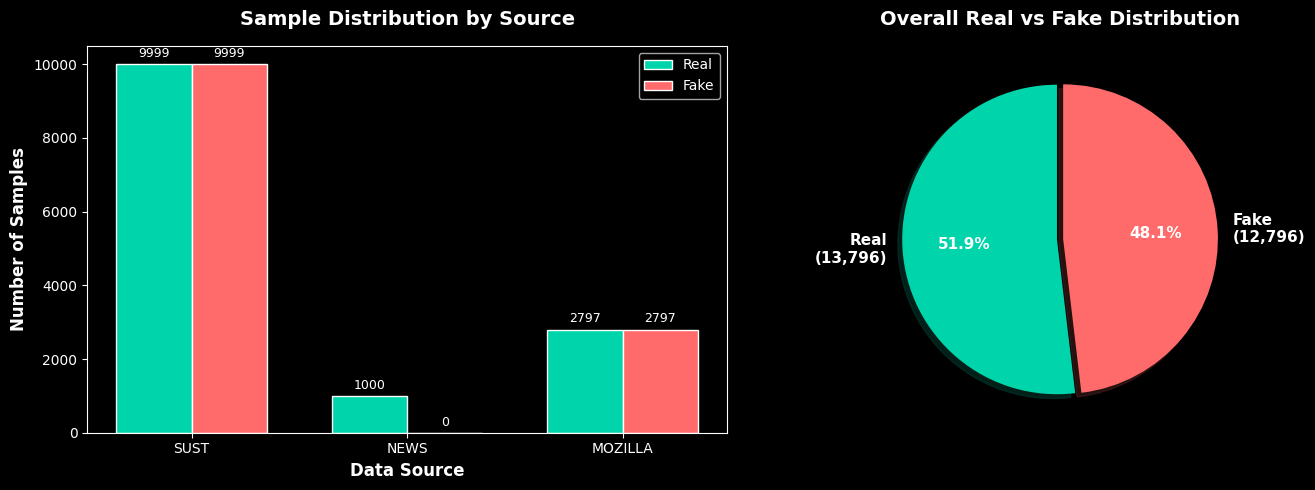

In [5]:
# Visualize dataset composition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart by source
sources = ['SUST', 'NEWS', 'MOZILLA']
real_counts = [len(all_files['sust']['real']), len(all_files['news']['real']), len(all_files['mozilla']['real'])]
fake_counts = [len(all_files['sust']['fake']), len(all_files['news']['fake']), len(all_files['mozilla']['fake'])]

x = np.arange(len(sources))
width = 0.35

bars1 = axes[0].bar(x - width/2, real_counts, width, label='Real', color=COLORS['real'], edgecolor='white')
bars2 = axes[0].bar(x + width/2, fake_counts, width, label='Fake', color=COLORS['fake'], edgecolor='white')

axes[0].set_xlabel('Data Source', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].set_title('Sample Distribution by Source', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(sources)
axes[0].legend(loc='upper right')
axes[0].bar_label(bars1, padding=3, fontsize=9)
axes[0].bar_label(bars2, padding=3, fontsize=9)

# Pie chart for overall distribution
sizes = [total_real, total_fake]
labels = [f'Real\n({total_real:,})', f'Fake\n({total_fake:,})']
colors_pie = [COLORS['real'], COLORS['fake']]
explode = (0.02, 0.02)

wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
    startangle=90, explode=explode, shadow=True,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[1].set_title('Overall Real vs Fake Distribution', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()


---
## 3. Audio Statistics & Properties

Analyze key audio properties: duration, sample rate, amplitude statistics.


In [6]:
def get_audio_stats(file_path: Path) -> dict:
    """
    Extract audio statistics from a single file.
    """
    try:
        info = sf.info(file_path)
        y, sr = librosa.load(file_path, sr=None, mono=True)
        
        return {
            'file': file_path.name,
            'duration': info.duration,
            'sample_rate': info.samplerate,
            'channels': info.channels,
            'samples': len(y),
            'rms': np.sqrt(np.mean(y**2)),
            'max_amplitude': np.max(np.abs(y)),
            'zero_crossings': np.sum(librosa.zero_crossings(y))
        }
    except Exception as e:
        return {'file': file_path.name, 'error': str(e)}


# Sample random files for statistics (to avoid processing all 26k+ files)
N_SAMPLES_PER_CLASS = 500

def sample_files(all_files_dict, n_per_class=N_SAMPLES_PER_CLASS):
    """Sample files from each source and class."""
    sampled = {'real': [], 'fake': []}
    
    for source, files in all_files_dict.items():
        for label in ['real', 'fake']:
            if files[label]:
                n = min(n_per_class, len(files[label]))
                sampled[label].extend(random.sample(files[label], n))
    
    return sampled

sampled_files = sample_files(all_files, N_SAMPLES_PER_CLASS)
print(f"Sampled {len(sampled_files['real'])} real and {len(sampled_files['fake'])} fake files for analysis.")


Sampled 1500 real and 1000 fake files for analysis.


In [7]:
# Collect statistics
stats_real = []
stats_fake = []

print("📈 Extracting audio statistics...")

for f in tqdm(sampled_files['real'], desc='Real samples'):
    stats = get_audio_stats(f)
    if 'error' not in stats:
        stats['label'] = 'real'
        stats_real.append(stats)

for f in tqdm(sampled_files['fake'], desc='Fake samples'):
    stats = get_audio_stats(f)
    if 'error' not in stats:
        stats['label'] = 'fake'
        stats_fake.append(stats)

stats_df = pd.DataFrame(stats_real + stats_fake)
print(f"\n✅ Collected stats for {len(stats_df)} audio files.")
stats_df.head(10)


📈 Extracting audio statistics...


Real samples:   0%|          | 0/1500 [00:00<?, ?it/s]

Fake samples:   0%|          | 0/1000 [00:00<?, ?it/s]


✅ Collected stats for 2500 audio files.


,file,duration,sample_rate,channels,samples,rms,max_amplitude,zero_crossings,label
0,03097.wav,8.922993,22050,1,196752,0.100004,0.299988,12977,real
1,01410.wav,1.307982,22050,1,28841,0.100012,0.370453,1275,real
2,08389.wav,4.814966,22050,1,106170,0.100009,0.312164,11297,real
3,07690.wav,6.057959,22050,1,133578,0.100014,0.283722,11568,real
4,07335.wav,10.441995,22050,1,230246,0.100003,0.350494,21190,real
5,03560.wav,5.653968,22050,1,124670,0.100002,0.439331,11024,real
6,02819.wav,1.587982,22050,1,35015,0.100005,0.346313,3776,real
7,13530.wav,6.893016,22050,1,151991,0.100006,0.416016,12041,real
8,02560.wav,8.047982,22050,1,177458,0.100018,0.396210,19775,real
9,14387.wav,3.939002,22050,1,86855,0.100007,0.273407,7512,real


In [8]:
# Summary statistics by class
print("\n📊 AUDIO STATISTICS SUMMARY")
print("="*70)

for label in ['real', 'fake']:
    subset = stats_df[stats_df['label'] == label]
    color = COLORS['real'] if label == 'real' else COLORS['fake']
    print(f"\n{'🎤 REAL AUDIO' if label == 'real' else '🤖 FAKE AUDIO'}:")
    print(f"  Sample Rate:      {subset['sample_rate'].mode().values[0]:,} Hz (mode)")
    print(f"  Duration (mean):  {subset['duration'].mean():.2f}s (σ={subset['duration'].std():.2f}s)")
    print(f"  Duration (range): [{subset['duration'].min():.2f}s, {subset['duration'].max():.2f}s]")
    print(f"  RMS Energy (mean):{subset['rms'].mean():.4f}")
    print(f"  Max Amplitude:    {subset['max_amplitude'].mean():.4f}")

print("\n" + "="*70)



📊 AUDIO STATISTICS SUMMARY

🎤 REAL AUDIO:
  Sample Rate:      22,050 Hz (mode)
  Duration (mean):  5.12s (σ=2.19s)
  Duration (range): [0.62s, 15.32s]
  RMS Energy (mean):0.1058
  Max Amplitude:    0.5548

🤖 FAKE AUDIO:
  Sample Rate:      22,050 Hz (mode)
  Duration (mean):  6.53s (σ=2.73s)
  Duration (range): [0.77s, 38.13s]
  RMS Energy (mean):0.0996
  Max Amplitude:    0.4722



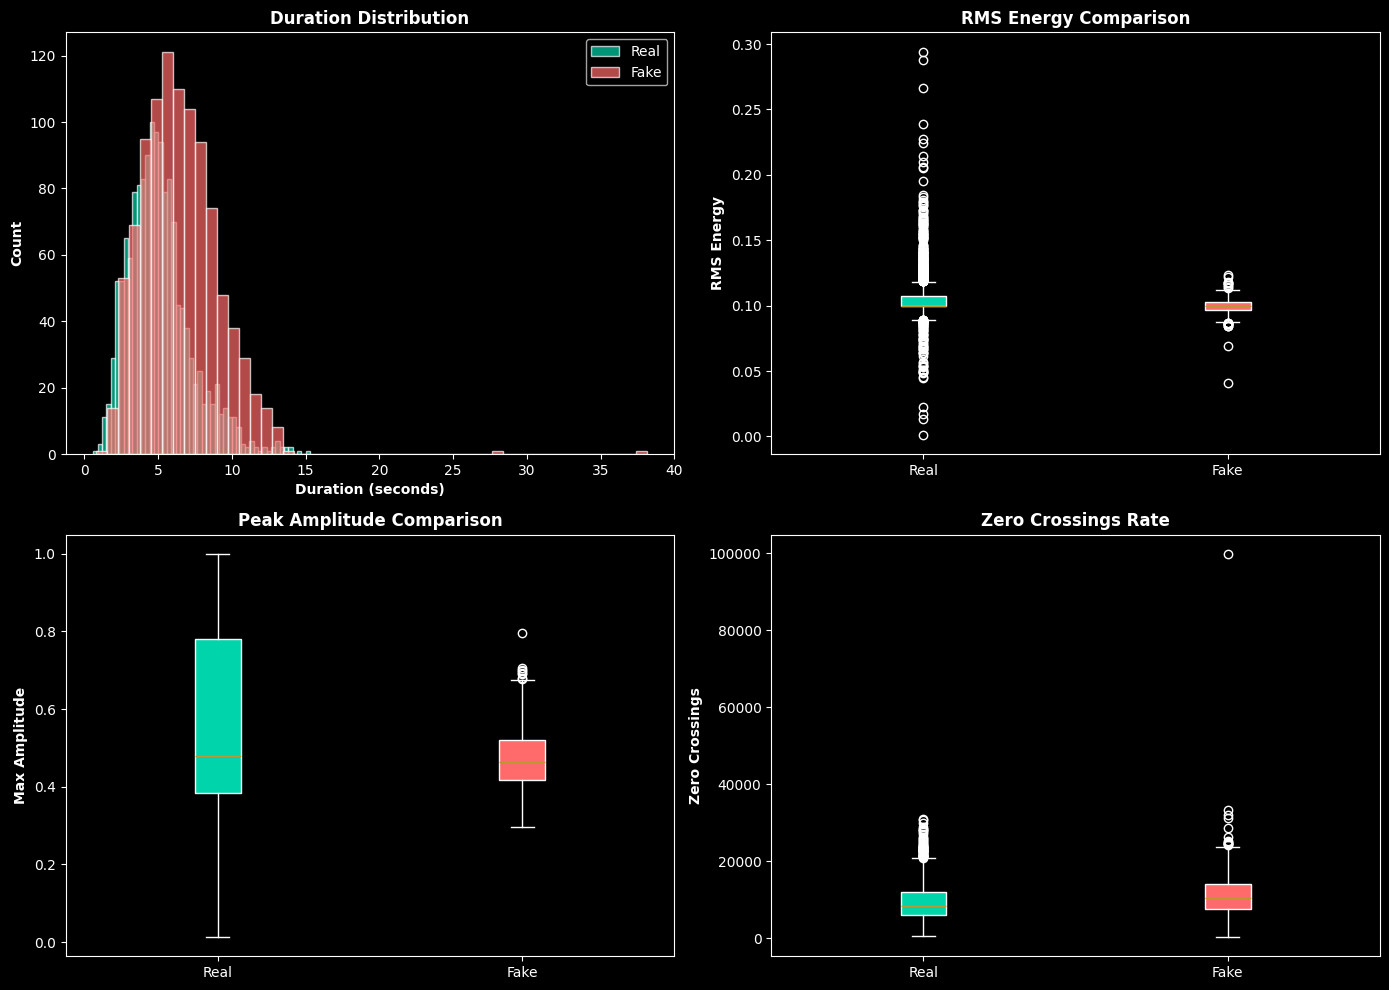

In [12]:
# Visualize duration distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Duration histogram
axes[0, 0].hist(stats_df[stats_df['label']=='real']['duration'], bins=50, alpha=0.7, 
                label='Real', color=COLORS['real'], edgecolor='white')
axes[0, 0].hist(stats_df[stats_df['label']=='fake']['duration'], bins=50, alpha=0.7, 
                label='Fake', color=COLORS['fake'], edgecolor='white')
axes[0, 0].set_xlabel('Duration (seconds)', fontweight='bold')
axes[0, 0].set_ylabel('Count', fontweight='bold')
axes[0, 0].set_title('Duration Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()

# RMS Energy boxplot
data_rms = [stats_df[stats_df['label']=='real']['rms'], stats_df[stats_df['label']=='fake']['rms']]
bp = axes[0, 1].boxplot(data_rms, tick_labels=['Real', 'Fake'], patch_artist=True)
bp['boxes'][0].set_facecolor(COLORS['real'])
bp['boxes'][1].set_facecolor(COLORS['fake'])
axes[0, 1].set_ylabel('RMS Energy', fontweight='bold')
axes[0, 1].set_title('RMS Energy Comparison', fontsize=12, fontweight='bold')

# Max amplitude comparison
data_amp = [stats_df[stats_df['label']=='real']['max_amplitude'], stats_df[stats_df['label']=='fake']['max_amplitude']]
bp2 = axes[1, 0].boxplot(data_amp, tick_labels=['Real', 'Fake'], patch_artist=True)
bp2['boxes'][0].set_facecolor(COLORS['real'])
bp2['boxes'][1].set_facecolor(COLORS['fake'])
axes[1, 0].set_ylabel('Max Amplitude', fontweight='bold')
axes[1, 0].set_title('Peak Amplitude Comparison', fontsize=12, fontweight='bold')

# Zero crossings comparison
data_zc = [stats_df[stats_df['label']=='real']['zero_crossings'], stats_df[stats_df['label']=='fake']['zero_crossings']]
bp3 = axes[1, 1].boxplot(data_zc, tick_labels=['Real', 'Fake'], patch_artist=True)
bp3['boxes'][0].set_facecolor(COLORS['real'])
bp3['boxes'][1].set_facecolor(COLORS['fake'])
axes[1, 1].set_ylabel('Zero Crossings', fontweight='bold')
axes[1, 1].set_title('Zero Crossings Rate', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('audio_statistics.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()


---
## 4. Waveform Visualization

Compare real vs fake audio waveforms to identify visual differences.


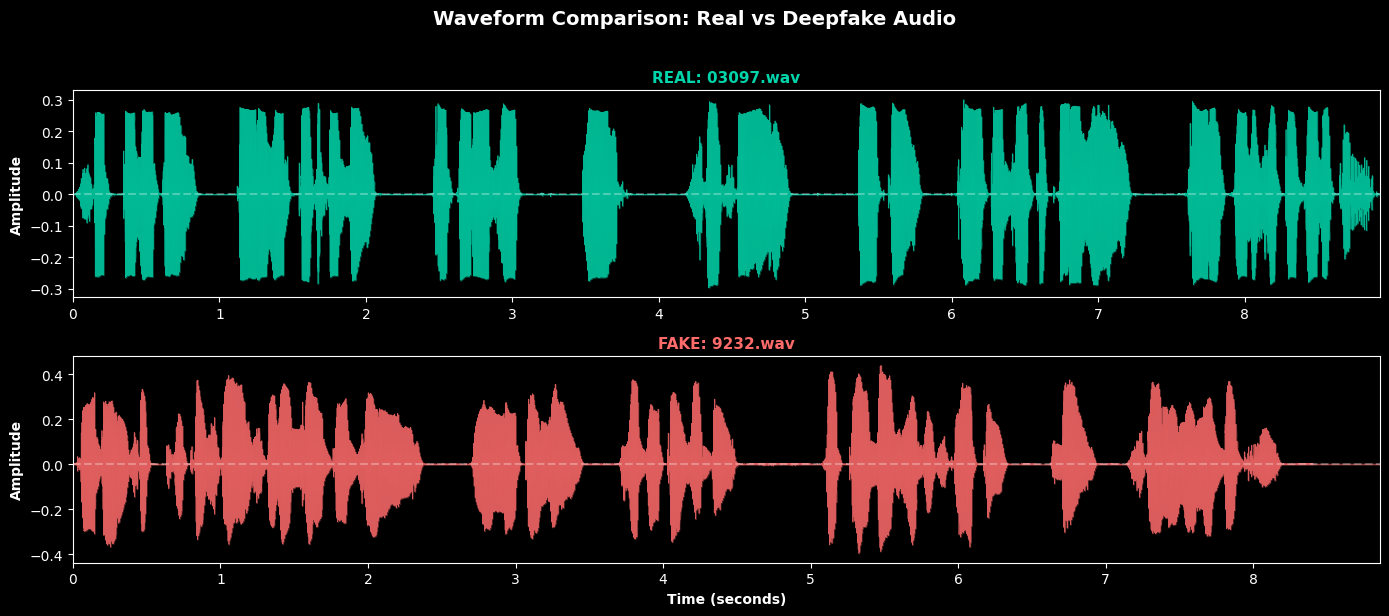

In [15]:
def plot_waveform_comparison(real_file: Path, fake_file: Path, title: str = ""):
    """
    Plot side-by-side waveform comparison of real and fake audio.
    """
    y_real, sr_real = librosa.load(real_file, sr=None)
    y_fake, sr_fake = librosa.load(fake_file, sr=None)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 6))
    
    # Real waveform
    times_real = np.arange(len(y_real)) / sr_real
    axes[0].plot(times_real, y_real, color=COLORS['real'], linewidth=0.5, alpha=0.8)
    axes[0].fill_between(times_real, y_real, alpha=0.3, color=COLORS['real'])
    axes[0].set_ylabel('Amplitude', fontweight='bold')
    axes[0].set_title(f'REAL: {real_file.name}', fontsize=11, fontweight='bold', color=COLORS['real'])
    axes[0].set_xlim([0, times_real[-1]])
    axes[0].axhline(y=0, color='white', linestyle='--', alpha=0.3)
    
    # Fake waveform
    times_fake = np.arange(len(y_fake)) / sr_fake
    axes[1].plot(times_fake, y_fake, color=COLORS['fake'], linewidth=0.5, alpha=0.8)
    axes[1].fill_between(times_fake, y_fake, alpha=0.3, color=COLORS['fake'])
    axes[1].set_xlabel('Time (seconds)', fontweight='bold')
    axes[1].set_ylabel('Amplitude', fontweight='bold')
    axes[1].set_title(f'FAKE: {fake_file.name}', fontsize=11, fontweight='bold', color=COLORS['fake'])
    axes[1].set_xlim([0, times_fake[-1]])
    axes[1].axhline(y=0, color='white', linestyle='--', alpha=0.3)
    
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    return fig


# Select samples for visualization
sample_real = sampled_files['real'][0]
sample_fake = sampled_files['fake'][0]

fig = plot_waveform_comparison(sample_real, sample_fake, "Waveform Comparison: Real vs Deepfake Audio")
plt.savefig('waveform_comparison.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()


In [16]:
# Listen to samples
print("🎧 Listen to the samples:")
print("\n--- REAL AUDIO ---")
display(Audio(sample_real))

print("\n--- FAKE AUDIO ---")
display(Audio(sample_fake))


🎧 Listen to the samples:

--- REAL AUDIO ---



--- FAKE AUDIO ---


---
## 5. Spectral Analysis

Deep dive into spectrograms and mel-spectrograms to identify frequency-domain artifacts.


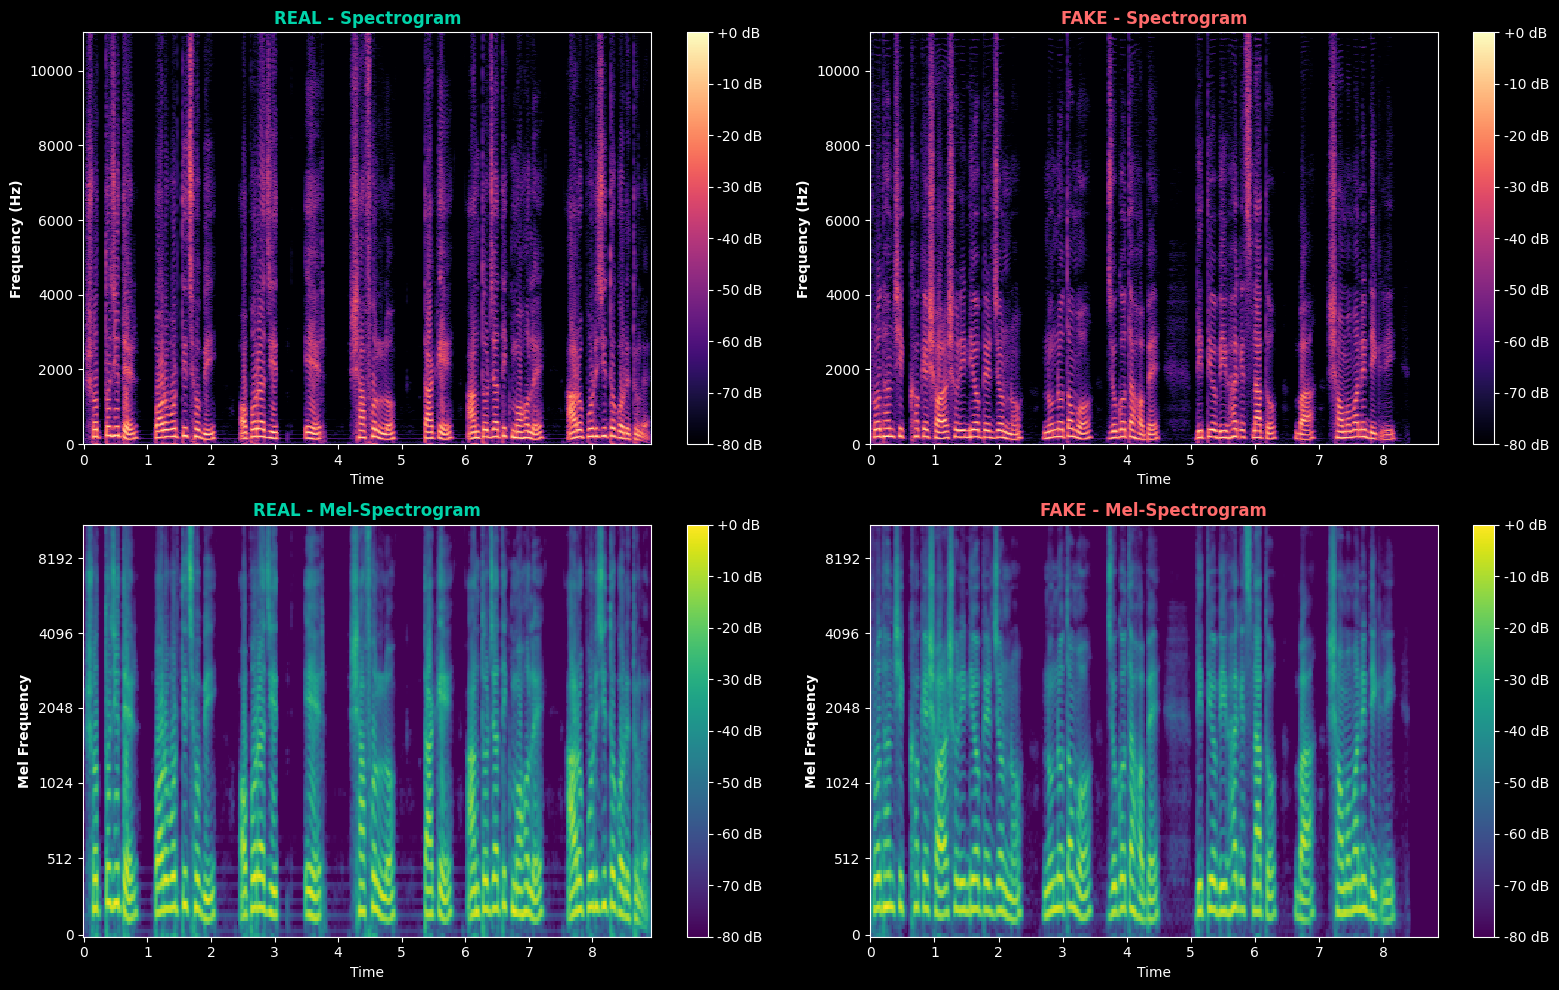

In [17]:
def plot_spectrogram_comparison(real_file: Path, fake_file: Path, n_fft=2048, hop_length=512):
    """
    Plot comprehensive spectral comparison: Spectrogram + Mel-Spectrogram.
    """
    y_real, sr_real = librosa.load(real_file, sr=None)
    y_fake, sr_fake = librosa.load(fake_file, sr=None)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Standard Spectrograms
    D_real = librosa.amplitude_to_db(np.abs(librosa.stft(y_real, n_fft=n_fft, hop_length=hop_length)), ref=np.max)
    D_fake = librosa.amplitude_to_db(np.abs(librosa.stft(y_fake, n_fft=n_fft, hop_length=hop_length)), ref=np.max)
    
    img1 = librosa.display.specshow(D_real, sr=sr_real, hop_length=hop_length, x_axis='time', y_axis='hz', ax=axes[0, 0], cmap='magma')
    axes[0, 0].set_title('REAL - Spectrogram', fontsize=12, fontweight='bold', color=COLORS['real'])
    axes[0, 0].set_ylabel('Frequency (Hz)', fontweight='bold')
    fig.colorbar(img1, ax=axes[0, 0], format='%+2.0f dB')
    
    img2 = librosa.display.specshow(D_fake, sr=sr_fake, hop_length=hop_length, x_axis='time', y_axis='hz', ax=axes[0, 1], cmap='magma')
    axes[0, 1].set_title('FAKE - Spectrogram', fontsize=12, fontweight='bold', color=COLORS['fake'])
    axes[0, 1].set_ylabel('Frequency (Hz)', fontweight='bold')
    fig.colorbar(img2, ax=axes[0, 1], format='%+2.0f dB')
    
    # Mel-Spectrograms
    mel_real = librosa.feature.melspectrogram(y=y_real, sr=sr_real, n_fft=n_fft, hop_length=hop_length, n_mels=128)
    mel_fake = librosa.feature.melspectrogram(y=y_fake, sr=sr_fake, n_fft=n_fft, hop_length=hop_length, n_mels=128)
    
    mel_real_db = librosa.power_to_db(mel_real, ref=np.max)
    mel_fake_db = librosa.power_to_db(mel_fake, ref=np.max)
    
    img3 = librosa.display.specshow(mel_real_db, sr=sr_real, hop_length=hop_length, x_axis='time', y_axis='mel', ax=axes[1, 0], cmap='viridis')
    axes[1, 0].set_title('REAL - Mel-Spectrogram', fontsize=12, fontweight='bold', color=COLORS['real'])
    axes[1, 0].set_ylabel('Mel Frequency', fontweight='bold')
    fig.colorbar(img3, ax=axes[1, 0], format='%+2.0f dB')
    
    img4 = librosa.display.specshow(mel_fake_db, sr=sr_fake, hop_length=hop_length, x_axis='time', y_axis='mel', ax=axes[1, 1], cmap='viridis')
    axes[1, 1].set_title('FAKE - Mel-Spectrogram', fontsize=12, fontweight='bold', color=COLORS['fake'])
    axes[1, 1].set_ylabel('Mel Frequency', fontweight='bold')
    fig.colorbar(img4, ax=axes[1, 1], format='%+2.0f dB')
    
    plt.tight_layout()
    return fig


fig = plot_spectrogram_comparison(sample_real, sample_fake)
plt.savefig('spectrogram_comparison.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()


In [18]:
# High-frequency analysis (where VITS artifacts are most prominent)
def analyze_high_frequency_content(file_path: Path, sr_target=22050, cutoff_hz=8000):
    """
    Analyze high-frequency content above a cutoff (where vocoder artifacts reside).
    """
    y, sr = librosa.load(file_path, sr=sr_target)
    
    # Compute spectrogram
    D = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)
    
    # Find high-frequency bins
    high_freq_idx = freqs >= cutoff_hz
    
    # Calculate energy in high frequencies
    high_freq_energy = np.mean(D[high_freq_idx, :])
    total_energy = np.mean(D)
    ratio = high_freq_energy / total_energy if total_energy > 0 else 0
    
    return {
        'high_freq_energy': high_freq_energy,
        'total_energy': total_energy,
        'high_freq_ratio': ratio
    }


# Analyze subset for high-frequency patterns
print("🔬 Analyzing high-frequency content (>8kHz) where vocoder artifacts typically appear...\n")

hf_stats_real = []
hf_stats_fake = []

for f in tqdm(sampled_files['real'][:200], desc='Real HF analysis'):
    hf_stats_real.append(analyze_high_frequency_content(f))

for f in tqdm(sampled_files['fake'][:200], desc='Fake HF analysis'):
    hf_stats_fake.append(analyze_high_frequency_content(f))

hf_real_ratios = [s['high_freq_ratio'] for s in hf_stats_real]
hf_fake_ratios = [s['high_freq_ratio'] for s in hf_stats_fake]

print(f"\nReal audio - High-freq ratio: mean={np.mean(hf_real_ratios):.4f}, std={np.std(hf_real_ratios):.4f}")
print(f"Fake audio - High-freq ratio: mean={np.mean(hf_fake_ratios):.4f}, std={np.std(hf_fake_ratios):.4f}")


🔬 Analyzing high-frequency content (>8kHz) where vocoder artifacts typically appear...



Real HF analysis:   0%|          | 0/200 [00:00<?, ?it/s]

Fake HF analysis:   0%|          | 0/200 [00:00<?, ?it/s]


Real audio - High-freq ratio: mean=0.1384, std=0.0515
Fake audio - High-freq ratio: mean=0.1246, std=0.0417


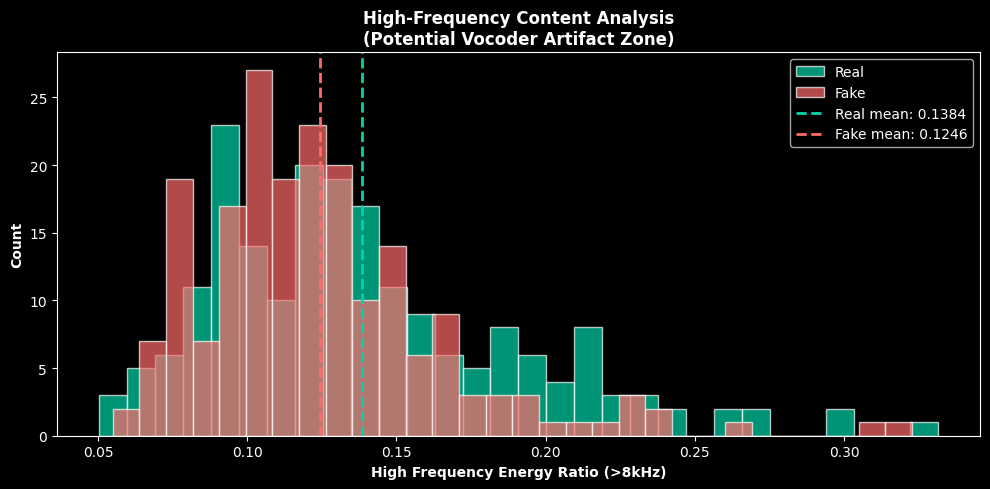

In [20]:
# Visualize high-frequency analysis
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(hf_real_ratios, bins=30, alpha=0.7, label='Real', color=COLORS['real'], edgecolor='white')
ax.hist(hf_fake_ratios, bins=30, alpha=0.7, label='Fake', color=COLORS['fake'], edgecolor='white')

ax.axvline(np.mean(hf_real_ratios), color=COLORS['real'], linestyle='--', linewidth=2, label=f'Real mean: {np.mean(hf_real_ratios):.4f}')
ax.axvline(np.mean(hf_fake_ratios), color=COLORS['fake'], linestyle='--', linewidth=2, label=f'Fake mean: {np.mean(hf_fake_ratios):.4f}')

ax.set_xlabel('High Frequency Energy Ratio (>8kHz)', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('High-Frequency Content Analysis\n(Potential Vocoder Artifact Zone)', fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('high_frequency_analysis.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()


---
## 6. MFCC Feature Analysis

Extract and visualize MFCC features - the traditional baseline for audio classification.


In [21]:
def extract_mfcc_features(file_path: Path, n_mfcc=13, sr_target=22050):
    """
    Extract MFCC features from audio file.
    Returns mean and std of each coefficient across time.
    """
    y, sr = librosa.load(file_path, sr=sr_target)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    
    return {
        'mfcc_mean': np.mean(mfccs, axis=1),
        'mfcc_std': np.std(mfccs, axis=1),
        'mfcc_full': mfccs
    }


# Extract MFCCs for samples
print("🎵 Extracting MFCC features...\n")

mfcc_real = []
mfcc_fake = []

for f in tqdm(sampled_files['real'][:200], desc='Real MFCC'):
    feat = extract_mfcc_features(f)
    mfcc_real.append(feat['mfcc_mean'])

for f in tqdm(sampled_files['fake'][:200], desc='Fake MFCC'):
    feat = extract_mfcc_features(f)
    mfcc_fake.append(feat['mfcc_mean'])

mfcc_real = np.array(mfcc_real)
mfcc_fake = np.array(mfcc_fake)

print(f"\nExtracted MFCC shapes: Real={mfcc_real.shape}, Fake={mfcc_fake.shape}")


🎵 Extracting MFCC features...



Real MFCC:   0%|          | 0/200 [00:00<?, ?it/s]

Fake MFCC:   0%|          | 0/200 [00:00<?, ?it/s]


Extracted MFCC shapes: Real=(200, 13), Fake=(200, 13)


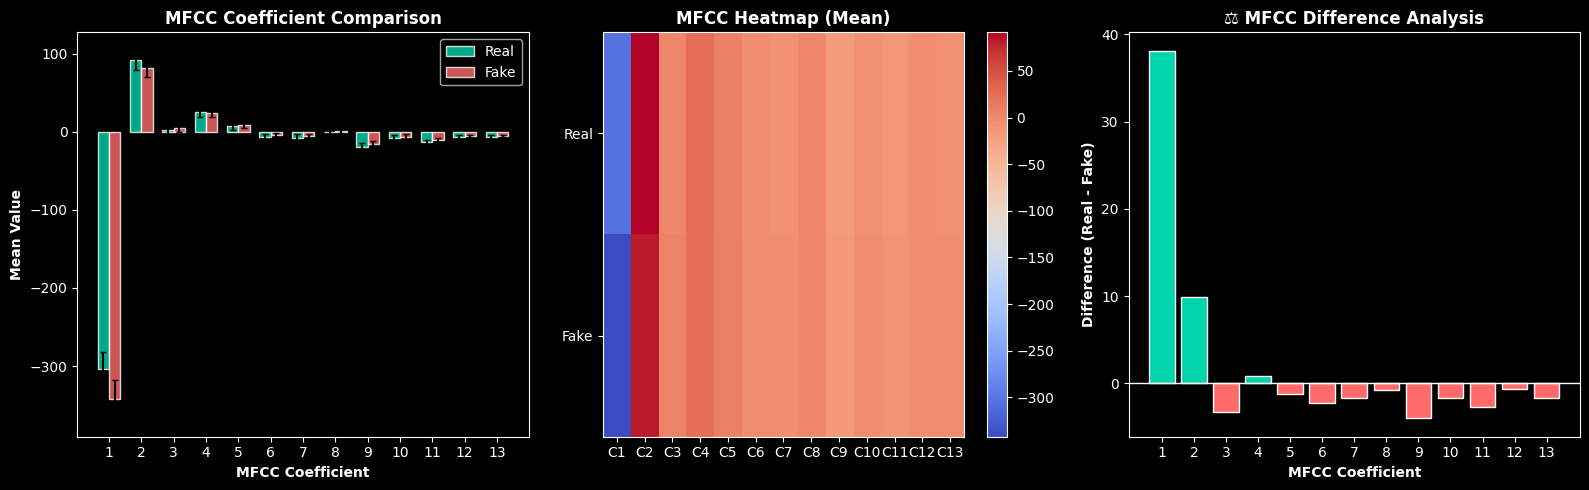

In [22]:
# MFCC comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Mean MFCC coefficients comparison
mfcc_indices = np.arange(1, 14)
width = 0.35

real_means = np.mean(mfcc_real, axis=0)
fake_means = np.mean(mfcc_fake, axis=0)
real_stds = np.std(mfcc_real, axis=0)
fake_stds = np.std(mfcc_fake, axis=0)

axes[0].bar(mfcc_indices - width/2, real_means, width, yerr=real_stds, label='Real', 
            color=COLORS['real'], edgecolor='white', capsize=2, alpha=0.8)
axes[0].bar(mfcc_indices + width/2, fake_means, width, yerr=fake_stds, label='Fake', 
            color=COLORS['fake'], edgecolor='white', capsize=2, alpha=0.8)
axes[0].set_xlabel('MFCC Coefficient', fontweight='bold')
axes[0].set_ylabel('Mean Value', fontweight='bold')
axes[0].set_title('MFCC Coefficient Comparison', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_xticks(mfcc_indices)

# Heatmap of average MFCCs
combined = np.vstack([np.mean(mfcc_real, axis=0).reshape(1, -1), np.mean(mfcc_fake, axis=0).reshape(1, -1)])
im = axes[1].imshow(combined, aspect='auto', cmap='coolwarm')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Real', 'Fake'])
axes[1].set_xticks(np.arange(13))
axes[1].set_xticklabels([f'C{i}' for i in range(1, 14)])
axes[1].set_title('MFCC Heatmap (Mean)', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=axes[1])

# MFCC difference (Real - Fake)
diff = real_means - fake_means
colors = [COLORS['real'] if d > 0 else COLORS['fake'] for d in diff]
axes[2].bar(mfcc_indices, diff, color=colors, edgecolor='white')
axes[2].axhline(y=0, color='white', linestyle='-', linewidth=1)
axes[2].set_xlabel('MFCC Coefficient', fontweight='bold')
axes[2].set_ylabel('Difference (Real - Fake)', fontweight='bold')
axes[2].set_title('⚖️ MFCC Difference Analysis', fontsize=12, fontweight='bold')
axes[2].set_xticks(mfcc_indices)

plt.tight_layout()
plt.savefig('mfcc_analysis.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()


🔮 Computing t-SNE embedding of MFCC features...


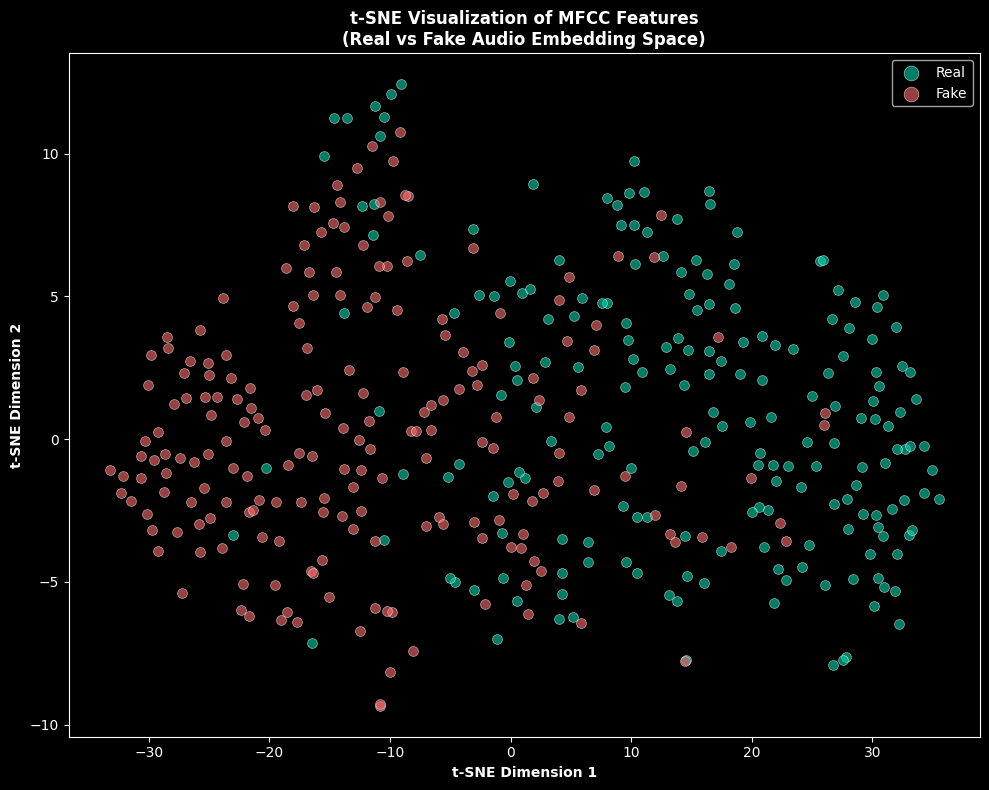


💡 Note: Overlapping clusters in MFCC space confirm findings from BanglaFake paper -
   MFCCs alone may not be sufficient for high-quality VITS detection.
   This motivates the use of SSL features (Wav2Vec2 XLSR) + AASIST architecture.


In [25]:
# t-SNE visualization of MFCC features
from sklearn.manifold import TSNE

print("🔮 Computing t-SNE embedding of MFCC features...")

# Combine features
X = np.vstack([mfcc_real, mfcc_fake])
labels = ['real'] * len(mfcc_real) + ['fake'] * len(mfcc_fake)

# t-SNE
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
X_embedded = tsne.fit_transform(X)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

real_mask = np.array(labels) == 'real'
fake_mask = np.array(labels) == 'fake'

ax.scatter(X_embedded[real_mask, 0], X_embedded[real_mask, 1], 
           c=COLORS['real'], label='Real', alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
ax.scatter(X_embedded[fake_mask, 0], X_embedded[fake_mask, 1], 
           c=COLORS['fake'], label='Fake', alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

ax.set_xlabel('t-SNE Dimension 1', fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontweight='bold')
ax.set_title('t-SNE Visualization of MFCC Features\n(Real vs Fake Audio Embedding Space)', fontsize=12, fontweight='bold')
ax.legend(markerscale=1.5)

plt.tight_layout()
plt.savefig('tsne_mfcc.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print("\n💡 Note: Overlapping clusters in MFCC space confirm findings from BanglaFake paper -")
print("   MFCCs alone may not be sufficient for high-quality VITS detection.")
print("   This motivates the use of SSL features (Wav2Vec2 XLSR) + AASIST architecture.")


---
## 7. Dataset Balance & Distribution Analysis


In [26]:
# Create comprehensive dataset manifest
def create_dataset_manifest(all_files_dict: dict) -> pd.DataFrame:
    """
    Create a unified manifest DataFrame with all audio files.
    """
    records = []
    
    for source, files in all_files_dict.items():
        for label in ['real', 'fake']:
            for f in files[label]:
                records.append({
                    'file_path': str(f),
                    'filename': f.name,
                    'source': source,
                    'label': label,
                    'label_id': 0 if label == 'real' else 1
                })
    
    return pd.DataFrame(records)


manifest_df = create_dataset_manifest(all_files)
print(f"📋 Created manifest with {len(manifest_df):,} samples")
print(f"\nLabel distribution:")
print(manifest_df['label'].value_counts())
print(f"\nSource distribution:")
print(manifest_df['source'].value_counts())


📋 Created manifest with 26,592 samples

Label distribution:
label
real    13796
fake    12796
Name: count, dtype: int64

Source distribution:
source
sust       19998
mozilla     5594
news        1000
Name: count, dtype: int64



📊 Source x Label Cross-Tabulation:
label     fake   real    All
source                      
mozilla   2797   2797   5594
news         0   1000   1000
sust      9999   9999  19998
All      12796  13796  26592


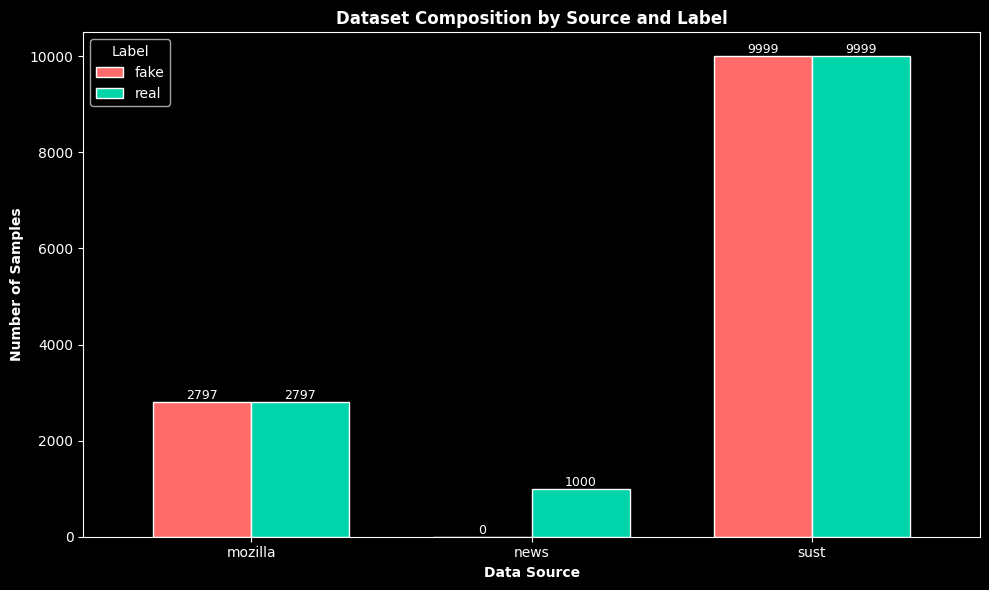

In [27]:
# Cross-tabulation of source and label
cross_tab = pd.crosstab(manifest_df['source'], manifest_df['label'], margins=True)
print("\n📊 Source x Label Cross-Tabulation:")
print(cross_tab)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))

cross_tab_no_margin = cross_tab.iloc[:-1, :-1]  # Remove margins for plotting
cross_tab_no_margin.plot(kind='bar', ax=ax, color=[COLORS['fake'], COLORS['real']], edgecolor='white', width=0.7)

ax.set_xlabel('Data Source', fontweight='bold')
ax.set_ylabel('Number of Samples', fontweight='bold')
ax.set_title('Dataset Composition by Source and Label', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Label')

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9)

plt.tight_layout()
plt.savefig('source_label_distribution.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()


---
## 8. Stratified Train/Val/Test Split (70/15/15)

Create balanced splits ensuring proportional representation from each source and label.


In [28]:
# Create stratification key combining source and label
manifest_df['stratify_key'] = manifest_df['source'] + '_' + manifest_df['label']

# First split: 70% train, 30% temp (for val+test)
train_df, temp_df = train_test_split(
    manifest_df, 
    test_size=0.30, 
    stratify=manifest_df['stratify_key'],
    random_state=SEED
)

# Second split: 50% val, 50% test (of the 30% temp) = 15% each
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['stratify_key'],
    random_state=SEED
)

# Assign split labels
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

print("📊 STRATIFIED DATA SPLIT SUMMARY")
print("="*50)
print(f"  Training:   {len(train_df):6,} samples ({100*len(train_df)/len(manifest_df):.1f}%)")
print(f"  Validation: {len(val_df):6,} samples ({100*len(val_df)/len(manifest_df):.1f}%)")
print(f"  Test:       {len(test_df):6,} samples ({100*len(test_df)/len(manifest_df):.1f}%)")
print("="*50)
print(f"  Total:      {len(manifest_df):6,} samples")


📊 STRATIFIED DATA SPLIT SUMMARY
  Training:   18,614 samples (70.0%)
  Validation:  3,989 samples (15.0%)
  Test:        3,989 samples (15.0%)
  Total:      26,592 samples


In [29]:
# Verify stratification
print("\n🔍 STRATIFICATION VERIFICATION")
print("="*70)

for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n{split_name} Set Distribution:")
    dist = split_df.groupby(['source', 'label']).size().unstack(fill_value=0)
    print(dist)
    print(f"  Label balance: Real={len(split_df[split_df['label']=='real'])}, Fake={len(split_df[split_df['label']=='fake'])}")



🔍 STRATIFICATION VERIFICATION

Train Set Distribution:
label    fake  real
source             
mozilla  1958  1958
news        0   700
sust     6999  6999
  Label balance: Real=9657, Fake=8957

Val Set Distribution:
label    fake  real
source             
mozilla   419   420
news        0   150
sust     1500  1500
  Label balance: Real=2070, Fake=1919

Test Set Distribution:
label    fake  real
source             
mozilla   420   419
news        0   150
sust     1500  1500
  Label balance: Real=2069, Fake=1920


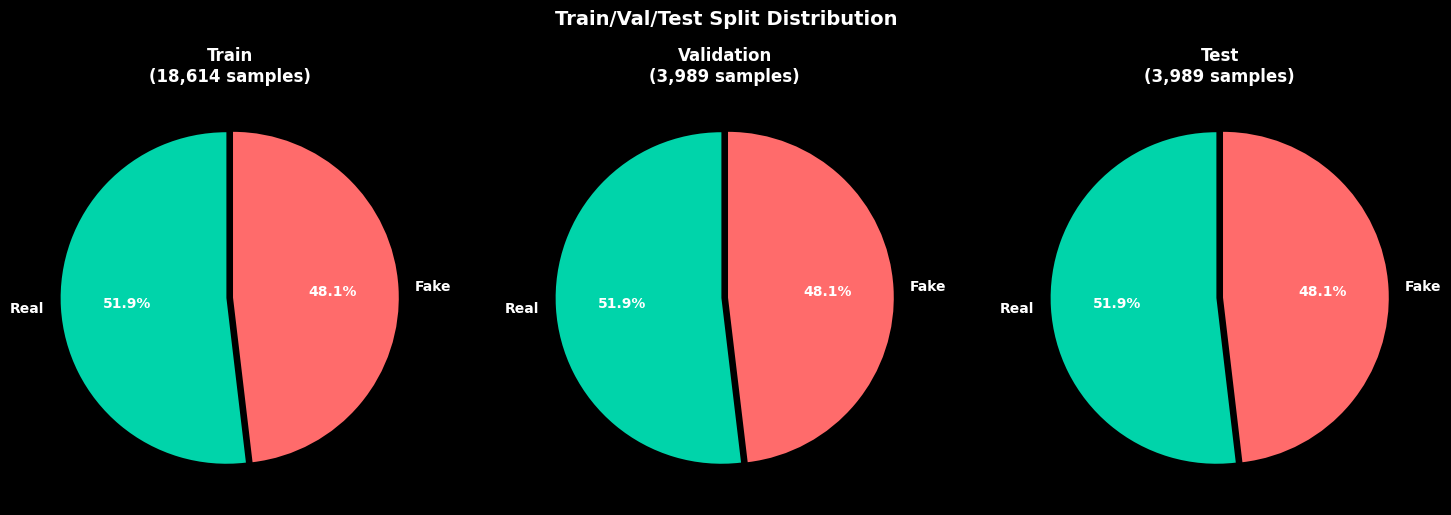

In [30]:
# Visualize split distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (split_name, split_df) in enumerate([('Train', train_df), ('Validation', val_df), ('Test', test_df)]):
    ax = axes[idx]
    
    real_count = len(split_df[split_df['label'] == 'real'])
    fake_count = len(split_df[split_df['label'] == 'fake'])
    
    wedges, texts, autotexts = ax.pie(
        [real_count, fake_count],
        labels=['Real', 'Fake'],
        colors=[COLORS['real'], COLORS['fake']],
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.02, 0.02),
        textprops={'fontweight': 'bold'}
    )
    ax.set_title(f'{split_name}\n({len(split_df):,} samples)', fontsize=12, fontweight='bold')

fig.suptitle('Train/Val/Test Split Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()


---
## 9. Data Export for Training Pipeline


In [31]:
# Combine all splits into final manifest
final_manifest = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Clean up columns
final_manifest = final_manifest[['file_path', 'filename', 'source', 'label', 'label_id', 'split']]

print(f"📋 Final manifest shape: {final_manifest.shape}")
final_manifest.head(10)


📋 Final manifest shape: (26592, 6)


,file_path,filename,source,label,label_id,split
0,..\final_data\deepfake_data_sust\deepfake_wav\...,2164.wav,sust,fake,1,train
1,..\final_data\deepfake_data_sust\real_wav\0635...,06357.wav,sust,real,0,train
2,..\final_data\deepfake_data_sust\real_wav\0613...,06134.wav,sust,real,0,train
3,..\final_data\deepfake_data_sust\deepfake_wav\...,13543.wav,sust,fake,1,train
4,..\final_data\deepfake_data_sust\real_wav\1340...,13405.wav,sust,real,0,train
5,..\final_data\deepfake_data_sust\real_wav\0657...,06574.wav,sust,real,0,train
6,..\final_data\deepfake_data_sust\real_wav\0838...,08385.wav,sust,real,0,train
7,..\final_data\deepfake_data_sust\deepfake_wav\...,11816.wav,sust,fake,1,train
8,..\final_data\deepfake_data_sust\real_wav\1210...,12109.wav,sust,real,0,train
9,..\final_data\deepfake_data_mozilla\deepfake_w...,common_voice_s1_142.wav,mozilla,fake,1,train


In [ ]:
# Export manifest files
OUTPUT_DIR = Path('./Manifest')
OUTPUT_DIR.mkdir(exist_ok=True)

# Full manifest
final_manifest.to_csv(OUTPUT_DIR / 'dataset_manifest.csv', index=False)

# Split-specific manifests
train_df[['file_path', 'filename', 'source', 'label', 'label_id']].to_csv(OUTPUT_DIR / 'train_manifest.csv', index=False)
            for f in files[label]:
                records.append({
                    'file_path': str(f),
                    'filename': f.name,
                    'source': source,
                    'label': label,
                    'label_id': 0 if label == 'real' else 1
                })


✅ Exported manifest files:
   - dataset_manifest.csv
   - train_manifest.csv
   - val_manifest.csv
   - test_manifest.csv


In [33]:
# Summary statistics for the pipeline
print("\n" + "="*70)
print("📋 FINAL DATASET SUMMARY FOR TRAINING PIPELINE")
print("="*70)
print(f"""
Dataset Statistics:
  - Total samples: {len(final_manifest):,}
  - Real samples:  {len(final_manifest[final_manifest['label']=='real']):,}
  - Fake samples:  {len(final_manifest[final_manifest['label']=='fake']):,}
  - Sample rate:   22,050 Hz (target)
  
Split Distribution:
  - Train: {len(train_df):,} ({100*len(train_df)/len(final_manifest):.1f}%)
  - Val:   {len(val_df):,} ({100*len(val_df)/len(final_manifest):.1f}%)
  - Test:  {len(test_df):,} ({100*len(test_df)/len(final_manifest):.1f}%)

Data Sources:
  - SUST: {len(final_manifest[final_manifest['source']=='sust']):,} (Real + VITS-generated)
  - Mozilla: {len(final_manifest[final_manifest['source']=='mozilla']):,} (Real + VITS-generated)
  - News: {len(final_manifest[final_manifest['source']=='news']):,} (Real only)

Key Findings from Analysis:
  1. MFCC features show significant overlap between real/fake classes
     → Confirms need for deep learning (XLSR-AASIST) over traditional features
  2. High-frequency content (>8kHz) shows subtle differences
     → Supports AASIST's spectro-temporal graph attention mechanism
  3. Dataset is nearly balanced (~50/50 real/fake split)
     → Standard binary cross-entropy or OC-Softmax loss applicable
  4. Current fake samples are VITS-only
     → Recommend augmentation with Crikk/Orpheus for generalization
""")
print("="*70)



📋 FINAL DATASET SUMMARY FOR TRAINING PIPELINE

Dataset Statistics:
  - Total samples: 26,592
  - Real samples:  13,796
  - Fake samples:  12,796
  - Sample rate:   22,050 Hz (target)

Split Distribution:
  - Train: 18,614 (70.0%)
  - Val:   3,989 (15.0%)
  - Test:  3,989 (15.0%)

Data Sources:
  - SUST: 19,998 (Real + VITS-generated)
  - Mozilla: 5,594 (Real + VITS-generated)
  - News: 1,000 (Real only)

Key Findings from Analysis:
  1. MFCC features show significant overlap between real/fake classes
     → Confirms need for deep learning (XLSR-AASIST) over traditional features
  2. High-frequency content (>8kHz) shows subtle differences
     → Supports AASIST's spectro-temporal graph attention mechanism
  3. Dataset is nearly balanced (~50/50 real/fake split)
     → Standard binary cross-entropy or OC-Softmax loss applicable
  4. Current fake samples are VITS-only
     → Recommend augmentation with Crikk/Orpheus for generalization



---
## 🔮 Next Steps

Based on this analysis, the recommended next steps for the Bengali-Vigil pipeline are:

1. **Data Augmentation** (as per PLAN.md Section 3.2):
   - Generate additional fake samples using Crikk TTS (~1,500 samples)
   - Generate samples using Orpheus-Bangla-TTS (Transformer-based)
   - Include emotional TTS samples for robustness

2. **RawBoost Augmentation**:
   - Implement linear/non-linear distortion
   - Add impulsive and colored noise
   - Apply codec compression (MP3/AAC) simulation

3. **Feature Extraction Pipeline**:
   - Set up Wav2Vec2 XLSR-53 feature extractor
   - Implement partial fine-tuning (freeze lower 12 layers)
   
4. **Model Training**:
   - Implement AASIST backend with XLSR embeddings
   - Configure OC-Softmax loss for algorithm-agnostic detection
   - Train with AdamW optimizer (differential learning rates)
